### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #6

## Support Vector Machines (SVM)

[SVM module documentation](https://scikit-learn.org/stable/modules/svm.html#svm)

[LinearSVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC)

[SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC  # fast but only linear
from sklearn.svm import SVC  # slower but can do kernels

In [3]:
# Load the iris data
iris = datasets.load_iris()
X = iris.data[:, 2:]
y = iris.target

print(X)
print(y)

[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [1.7 0.4]
 [1.4 0.3]
 [1.5 0.2]
 [1.4 0.2]
 [1.5 0.1]
 [1.5 0.2]
 [1.6 0.2]
 [1.4 0.1]
 [1.1 0.1]
 [1.2 0.2]
 [1.5 0.4]
 [1.3 0.4]
 [1.4 0.3]
 [1.7 0.3]
 [1.5 0.3]
 [1.7 0.2]
 [1.5 0.4]
 [1.  0.2]
 [1.7 0.5]
 [1.9 0.2]
 [1.6 0.2]
 [1.6 0.4]
 [1.5 0.2]
 [1.4 0.2]
 [1.6 0.2]
 [1.6 0.2]
 [1.5 0.4]
 [1.5 0.1]
 [1.4 0.2]
 [1.5 0.2]
 [1.2 0.2]
 [1.3 0.2]
 [1.4 0.1]
 [1.3 0.2]
 [1.5 0.2]
 [1.3 0.3]
 [1.3 0.3]
 [1.3 0.2]
 [1.6 0.6]
 [1.9 0.4]
 [1.4 0.3]
 [1.6 0.2]
 [1.4 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [4.7 1.4]
 [4.5 1.5]
 [4.9 1.5]
 [4.  1.3]
 [4.6 1.5]
 [4.5 1.3]
 [4.7 1.6]
 [3.3 1. ]
 [4.6 1.3]
 [3.9 1.4]
 [3.5 1. ]
 [4.2 1.5]
 [4.  1. ]
 [4.7 1.4]
 [3.6 1.3]
 [4.4 1.4]
 [4.5 1.5]
 [4.1 1. ]
 [4.5 1.5]
 [3.9 1.1]
 [4.8 1.8]
 [4.  1.3]
 [4.9 1.5]
 [4.7 1.2]
 [4.3 1.3]
 [4.4 1.4]
 [4.8 1.4]
 [5.  1.7]
 [4.5 1.5]
 [3.5 1. ]
 [3.8 1.1]
 [3.7 1. ]
 [3.9 1.2]
 [5.1 1.6]
 [4.5 1.5]
 [4.5 1.6]
 [4.7 1.5]
 [4.4 1.3]
 [4.1 1.3]
 [4.  1.3]
 [4.4 1.2]

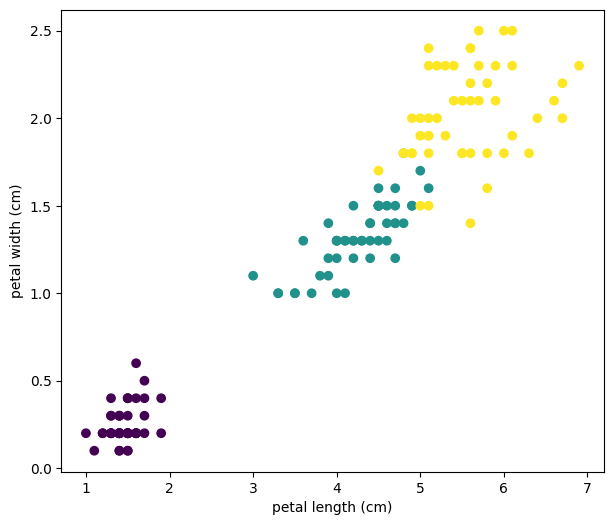

In [4]:
# Plot the data
plt.figure(figsize=(7,6))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.show()

#### In this problem, you'll use support vector machines to classify the Iris data

#### The following function helps you plot the decision boundary.

In [5]:
# Plot the decision boundaries
def plot_decision_boundary(clf, X, y):
    h = 0.005  # Boundary lines' resolution
    x_min, x_max = X[:,0].min() - 10*h, X[:,0].max() + 10*h
    y_min, y_max = X[:,1].min() - 10*h, X[:,1].max() + 10*h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, Z, alpha=0.25)  # Background
    plt.contour(xx, yy, Z, colors='k', linewidths=0.2)  # Boundary lines
    plt.scatter(X[:,0], X[:,1], c=y);  # Data points
    plt.xlabel(iris.feature_names[2])
    plt.ylabel(iris.feature_names[3])

#### Exercise 1. Split the data into training set and test set.

In [6]:
X_train, X_test , y_train, y_test = train_test_split(X,y , test_size=0.3)

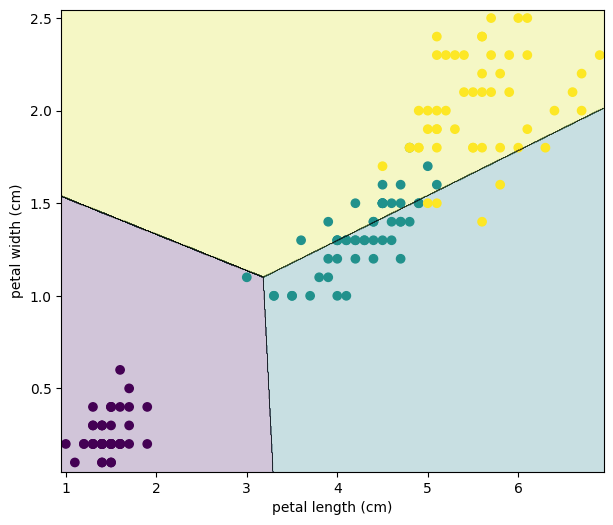

In [7]:
linsvm = LinearSVC(C=0.1)

linsvm.fit(X_train, y_train)

plot_decision_boundary(linsvm, X,y)

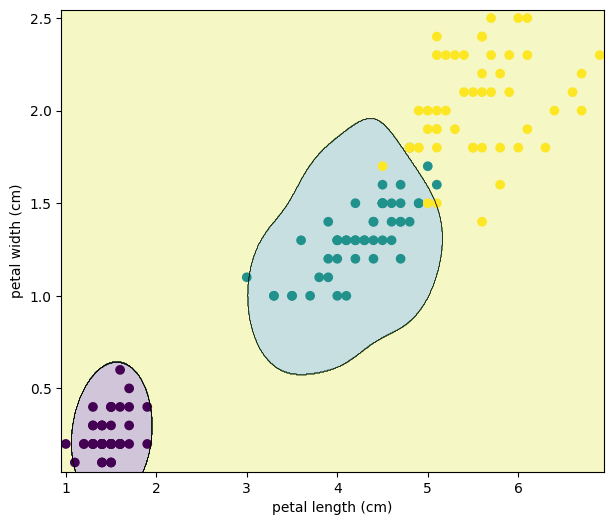

In [8]:
svm = SVC(C=0.1, kernel='rbf', gamma= 10)

svm.fit(X_train , y_train)

plot_decision_boundary(svm, X , y)


#### Exercise 2. Learn a linear SVM classifier using sklearn.svm.LinearSVC. You will need to set `loss='hinge'`.

#### Try different values of the tradeoff parameter: `C = 0.01, 0.1, 1.0, 10.0, 100.0` and use `plot_decision_boundary` to plot the decision boundary.

#### If you encounter `RuntimeError`, consider setting `max_iter=100000`

#### What is the effect of `C` on the decision boundary?

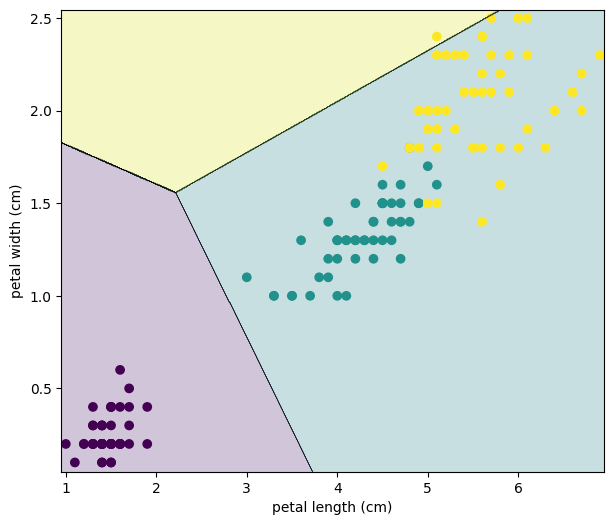

In [9]:
linsvm001 =  LinearSVC(C=0.01, loss='hinge', max_iter=100000)

linsvm001.fit(X_train, y_train)

plot_decision_boundary(linsvm001, X,y)

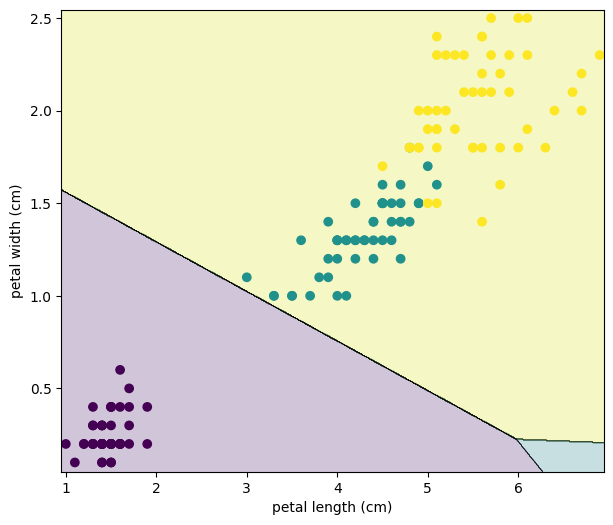

In [10]:
linsvm01 =  LinearSVC(C=0.1, loss='hinge', max_iter=100000)

linsvm01.fit(X_train, y_train)

plot_decision_boundary(linsvm01, X,y)

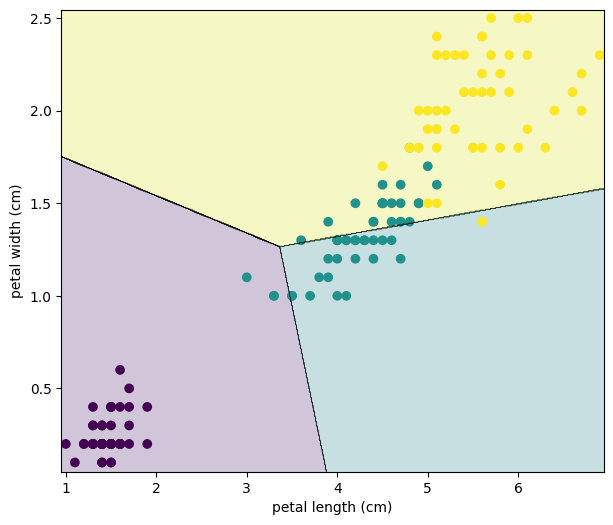

In [11]:
linsvm1 =  LinearSVC(C=1, loss='hinge', max_iter=100000)

linsvm1.fit(X_train, y_train)

plot_decision_boundary(linsvm1, X,y)

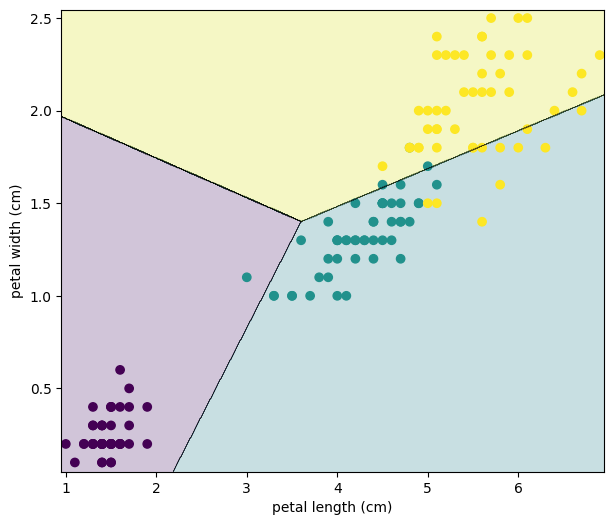

In [12]:
linsvm10 =  LinearSVC(C=10, loss='hinge', max_iter=100000)

linsvm10.fit(X_train, y_train)

plot_decision_boundary(linsvm10, X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


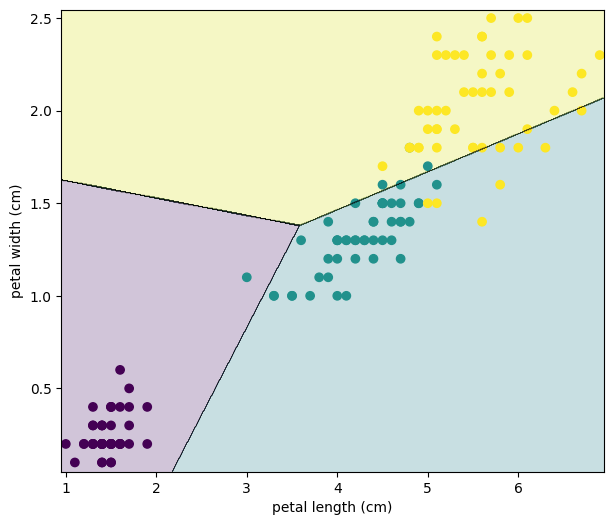

In [13]:
linsvm100 =  LinearSVC(C=100.0, loss='hinge', max_iter=100000)

linsvm100.fit(X_train, y_train)

plot_decision_boundary(linsvm100, X,y)

##When C value is high = classify is more obvious but risky overfitting
##in otherword,
##low C value = classify is less obvious but easier to interpret

#### Exercise 3. Pick a value of `C` that you like. Then report the test error.

In [14]:
from sklearn.metrics import accuracy_score

y_pred = linsvm10.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
score_svc = 1 - accuracy

print(score_svc)

0.1777777777777778


#### Exercise 4. Now try kernel SVM with a quadratic kernel. You can do this with sklearn.svm.SVC, setting `kernel='rbf'` and `C = 1.0`.

#### Try different values of the tradeoff parameter: `gamma = 0.01, 0.1, 1.0, 10.0, 100.0` and use `plot_decision_boundary` to plot the decision boundary.

#### If you encounter `RuntimeError`, consider setting `max_iter=100000`

#### What is the effect of `gamma` on the decision boundary?

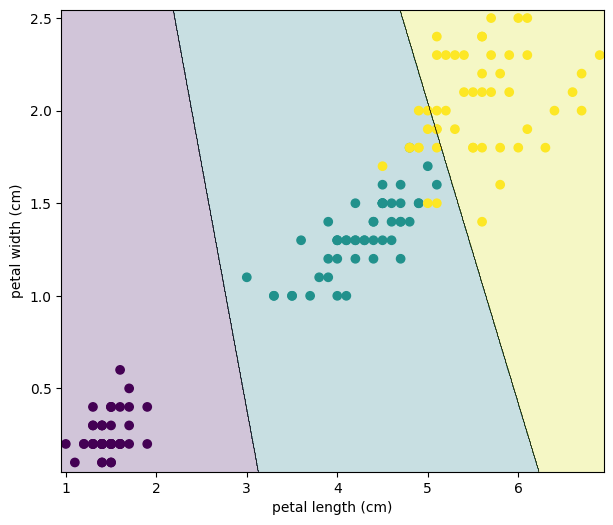

In [15]:
svmgam001 = SVC(C=1.0, kernel='rbf' ,gamma=0.01 ,max_iter=100000)

svmgam001.fit(X_train, y_train)

plot_decision_boundary(svmgam001, X, y)

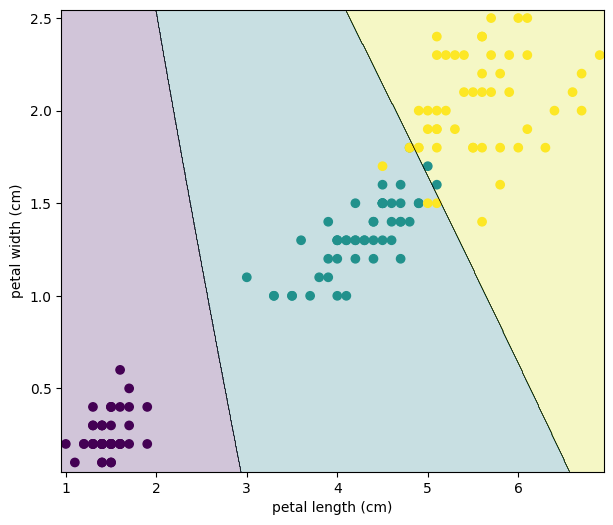

In [16]:
svmgam01 = SVC(C=1.0, kernel='rbf' ,gamma=0.1 ,max_iter=100000)

svmgam01.fit(X_train, y_train)

plot_decision_boundary(svmgam01, X, y)

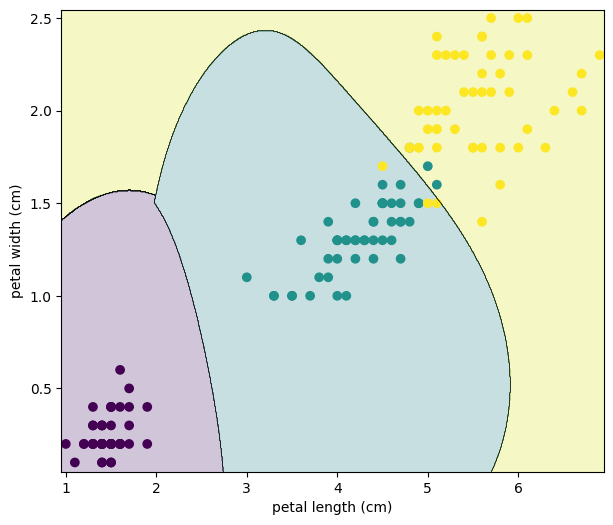

In [17]:
svmgam1 = SVC(C=1.0, kernel='rbf' ,gamma=1.0 ,max_iter=100000)

svmgam1.fit(X_train, y_train)

plot_decision_boundary(svmgam1, X, y)

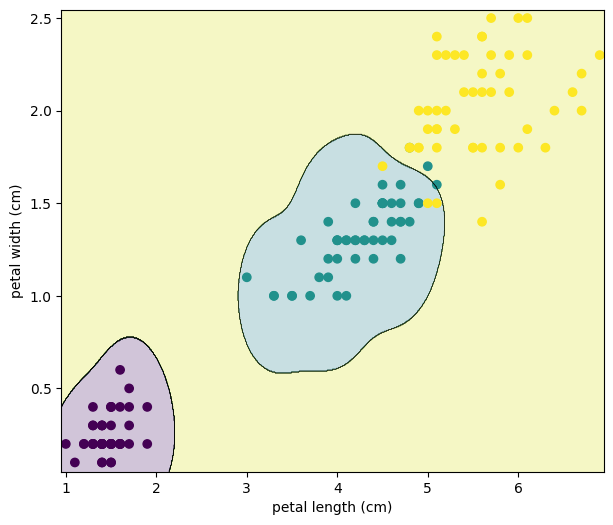

In [18]:
svmgam10 = SVC(C=1.0, kernel='rbf' ,gamma=10.0 ,max_iter=100000)

svmgam10.fit(X_train, y_train)

plot_decision_boundary(svmgam10, X, y)

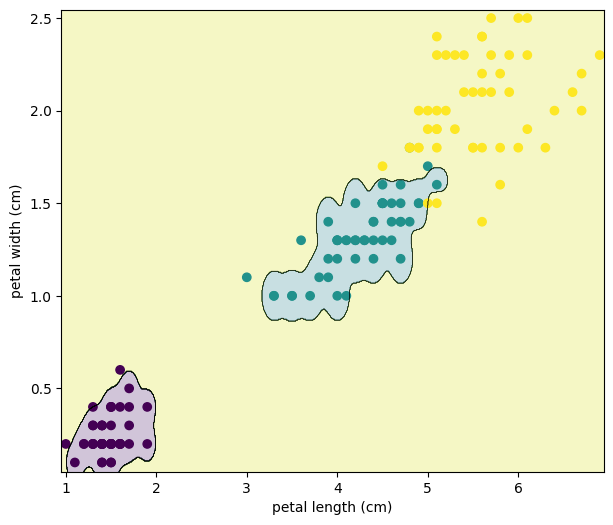

In [19]:
svmgam100 = SVC(C=1.0, kernel='rbf' ,gamma=100.0 ,max_iter=100000)

svmgam100.fit(X_train, y_train)

plot_decision_boundary(svmgam100, X, y)

* High gamma  = the line is more polygon but use more time
* Low gamma  =

#### Exercise 5. Pick a value of `gamma` that you like. Then report the test error and the number of support vectors.

In [21]:
y_pred = svmgam100.predict(X_test)

acc = accuracy_score(y_test,y_pred)
score_svm = 1 - acc

print(score_svm)

0.1333333333333333


#### Exercise 6. Between Linear SVM and Kernel SVM, which model would you prefer to use for classification of Iris data?
1. Explain using test accuracy
2. Explaing using decision boundary plot

##**1. Explanation using test accuracy**

**Linear SVM works well only if classes are approximately linearly separable but if the data is not distribution much more they will be less accurate so we do not recommend this case, while Kernel SVM is more useful with data with less distribution. For summary I prefer Kernel SVM for more accuracy.**

 ## **2.Explaing using decision boundary plot**

**Linear SVM produces a straight-line decision boundary, cannot adapt to the curved structure of the data, while  Kernel SVM  produces a nonlinear, curved decision boundary. It flexibly follows the shape of the data clusters and separates overlapping classes more effectively.**
